<a href="https://colab.research.google.com/github/w4bo/AA2627-unibo-mldm/blob/master/slides/lab-04-clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
title: "Machine Learning and Data Mining (Module I)"
subtitle: "Clustering"
---

We will:

- normalize numeric attributes before Euclidean-distance clustering;
- inspect K-means centroids, per-cluster dispersion, sizes, iterations, and SSE;
- evaluate Iris clusters against the known species without using the species during training;
- interpret Food Nutrient partitions for increasing values of $k$;
- compare K-means and DBSCAN on the elongated clusters in Coordinates.

In [41]:
#| echo: false
#| output: false

# %pip install -q numpy pandas matplotlib scipy scikit-learn

from pathlib import Path
from itertools import permutations
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import arff
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import confusion_matrix, silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (8, 5), "axes.spines.top": False, "axes.spines.right": False})


def find_datasets_dir():
    # Locate the repository's local ARFF dataset directory.
    candidates = [Path("datasets"), Path("slides/datasets"), Path.cwd() / "slides" / "datasets"]
    for candidate in candidates:
        if (candidate / "iris.arff").exists():
            return candidate.resolve()
    raise FileNotFoundError("Could not find slides/datasets. Start the notebook in the repository root or slides/.")


DATASETS = find_datasets_dir()
DATASETS


PosixPath('/home/slides/datasets')

In [42]:
#| echo: false
#| output: false

def load_arff_frame(filename):
    # Load a local ARFF file and decode byte-valued nominal columns.
    records, _ = arff.loadarff(DATASETS / filename)
    frame = pd.DataFrame(records)
    for column in frame.columns:
        if frame[column].dtype == object:
            frame[column] = frame[column].map(
                lambda value: value.decode("utf-8") if isinstance(value, bytes) else value
            )
    return frame


def cluster_summary(X_scaled, labels, centers, feature_names):
    # Weka-like centroid, size, and per-attribute standard-deviation tables.
    center_df = pd.DataFrame(centers, columns=feature_names)
    center_df.index = [f"C{i}" for i in range(len(center_df))]
    std_df = pd.DataFrame(
        [X_scaled[labels == i].std(axis=0, ddof=0) for i in range(len(centers))],
        columns=feature_names,
        index=center_df.index,
    )
    sizes = pd.Series(labels).value_counts().sort_index()
    sizes.index = center_df.index
    sizes.name = "size"
    return center_df, std_df, sizes


def best_cluster_class_mapping(y_true, cluster_labels):
    # Map cluster IDs to classes to maximize correct assignments.
    classes = np.unique(y_true)
    clusters = np.unique(cluster_labels)
    table = pd.crosstab(
        pd.Series(cluster_labels, name="cluster"),
        pd.Series(y_true, name="class"),
    ).reindex(index=clusters, columns=classes, fill_value=0)
    best = None
    for perm in permutations(classes, len(clusters)):
        score = sum(table.loc[cluster, klass] for cluster, klass in zip(clusters, perm))
        if best is None or score > best[0]:
            best = (score, dict(zip(clusters, perm)))
    predicted = np.array([best[1][cluster] for cluster in cluster_labels])
    return table, best[1], predicted, best[0] / len(y_true)


# The Iris dataset

Iris contains 150 plants, four numeric measurements, and no missing values. 

- `class` is excluded from the distance computation and used only after clustering for external evaluation.


## Iris schema


In [43]:
iris = load_arff_frame("iris.arff")
iris.info()


<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sepallength  150 non-null    float64
 1   sepalwidth   150 non-null    float64
 2   petallength  150 non-null    float64
 3   petalwidth   150 non-null    float64
 4   class        150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


## Iris summary


In [44]:
iris.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
sepallength,150.0,NaN,NaN,NaN,5.843333,0.828066,4.3,5.1,5.8,6.4,7.9
sepalwidth,150.0,NaN,NaN,NaN,3.054,0.433594,2.0,2.8,3.0,3.3,4.4
petallength,150.0,NaN,NaN,NaN,3.758667,1.76442,1.0,1.6,4.35,5.1,6.9
petalwidth,150.0,NaN,NaN,NaN,1.198667,0.763161,0.1,0.3,1.3,1.8,2.5
class,150,3,Iris-setosa,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Preprocessing: normalize before Euclidean distance

Distance-based algorithms are sensitive to scale.


In [45]:
iris_features = ["sepallength", "sepalwidth", "petallength", "petalwidth"]
X_iris = iris[iris_features].to_numpy()
y_iris = iris["class"].to_numpy()

iris_scaler = MinMaxScaler()
X_iris_scaled = iris_scaler.fit_transform(X_iris)

pd.DataFrame(X_iris_scaled, columns=iris_features).agg(["min", "max"])


,sepallength,sepalwidth,petallength,petalwidth
min,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0


# Simple K-means

`n_init=10` deliberately tries several initializations and retains the lowest-SSE result.

- Fixing `random_state` makes this notebook reproducible.


In [46]:
iris_kmeans = KMeans(n_clusters=3, n_init=10, max_iter=500, random_state=10)
iris_clusters = iris_kmeans.fit_predict(X_iris_scaled)

iris_centers, iris_stds, iris_sizes = cluster_summary(
    X_iris_scaled, iris_clusters, iris_kmeans.cluster_centers_, iris_features
)

print(f"Iterations to convergence: {iris_kmeans.n_iter_}")
print(f"SSE / inertia: {iris_kmeans.inertia_:.4f}")


Iterations to convergence: 7
SSE / inertia: 6.9981


# Simple K-means

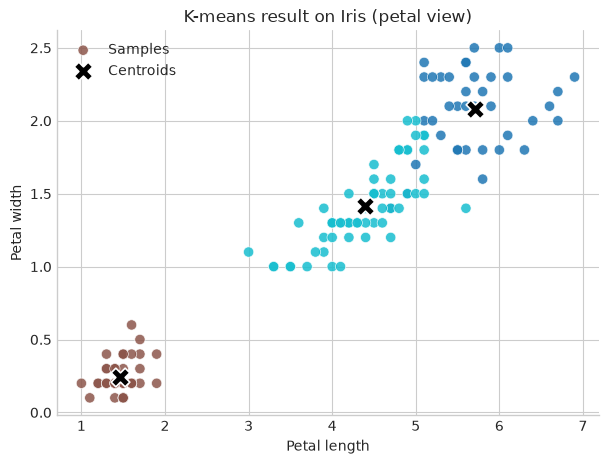

In [47]:
fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(iris["petallength"], iris["petalwidth"], c=iris_clusters, cmap="tab10", s=55, alpha=0.85, edgecolor="white", linewidth=0.5, label="Samples",)
centers_original = iris_scaler.inverse_transform(iris_kmeans.cluster_centers_)
ax.scatter(centers_original[:, 2], centers_original[:, 3], c="black", marker="X", s=180, linewidth=1.2, edgecolor="white", label="Centroids",)
ax.set_title("K-means result on Iris (petal view)")
ax.set_xlabel("Petal length")
ax.set_ylabel("Petal width")
ax.legend(loc="best")
plt.show()


## Iris cluster


In [48]:
iris_sizes.to_frame()


,size
C0,39
C1,50
C2,61


In [49]:
iris_centers.round(4)


,sepallength,sepalwidth,petallength,petalwidth
C0,0.7073,0.4509,0.7970,0.8248
C1,0.1961,0.5908,0.0786,0.0600
C2,0.4413,0.3074,0.5757,0.5492


In [50]:
iris_stds.round(4)


,sepallength,sepalwidth,petallength,petalwidth
C0,0.1378,0.1151,0.0869,0.1156
C1,0.0969,0.1572,0.0291,0.0442
C2,0.1236,0.1212,0.0886,0.1125


## Iris cluster-to-class matching

Cluster IDs have no semantic order.

- We therefore find the one-to-one mapping from clusters to Iris species that maximizes the diagonal of the contingency table.

In [51]:
iris_table, iris_mapping, iris_predicted_class, iris_accuracy = best_cluster_class_mapping(y_iris, iris_clusters)
iris_table


class,Iris-setosa,Iris-versicolor,Iris-virginica
cluster,,,
0,0,3,36
1,50,0,0
2,0,47,14


## Iris matched-class confusion matrix


In [52]:
print("Cluster-to-class mapping:", {f"C{k}": v for k, v in iris_mapping.items()})
print(f"Correctly matched: {iris_accuracy:.1%}")
print(f"Incorrectly matched: {1 - iris_accuracy:.1%} ({np.sum(iris_predicted_class != y_iris)} plants)")

cm = pd.DataFrame(
    confusion_matrix(y_iris, iris_predicted_class, labels=np.unique(y_iris)),
    index=[f"true: {c}" for c in np.unique(y_iris)],
    columns=[f"pred: {c}" for c in np.unique(y_iris)],
)
cm


Cluster-to-class mapping: {'C0': 'Iris-virginica', 'C1': 'Iris-setosa', 'C2': 'Iris-versicolor'}
Correctly matched: 88.7%
Incorrectly matched: 11.3% (17 plants)


,pred: Iris-setosa,pred: Iris-versicolor,pred: Iris-virginica
true: Iris-setosa,50,0,0
true: Iris-versicolor,0,47,3
true: Iris-virginica,0,14,36


## Visual analysis across pairs of attributes

- Setosa should appear well separated.
- Versicolor and virginica overlap most strongly on sepal length and sepal width, while the petal measurements provide clearer separation.


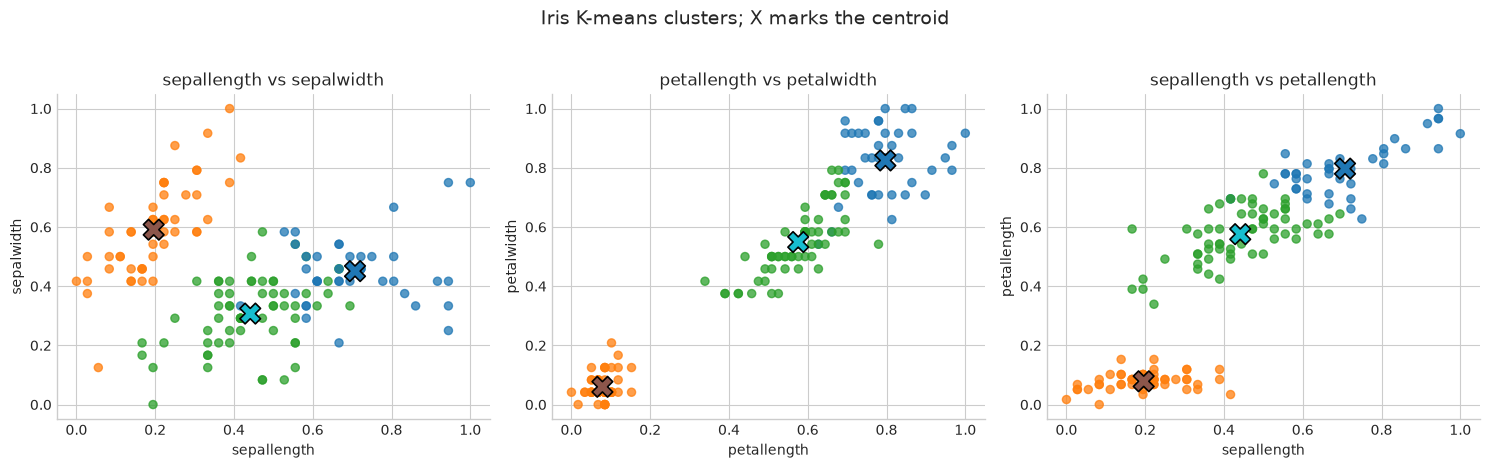

In [53]:
#| echo: false

pairs = [
    ("sepallength", "sepalwidth"),
    ("petallength", "petalwidth"),
    ("sepallength", "petallength"),
]
feature_index = {name: i for i, name in enumerate(iris_features)}
colors = plt.cm.tab10(iris_clusters)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (x_name, y_name) in zip(axes, pairs):
    x_idx, y_idx = feature_index[x_name], feature_index[y_name]
    ax.scatter(X_iris_scaled[:, x_idx], X_iris_scaled[:, y_idx], c=colors, s=34, alpha=.75)
    ax.scatter(
        iris_kmeans.cluster_centers_[:, x_idx], iris_kmeans.cluster_centers_[:, y_idx],
        marker="X", s=220, c=range(3), cmap="tab10", edgecolor="black", linewidth=1.2,
    )
    ax.set(xlabel=x_name, ylabel=y_name, title=f"{x_name} vs {y_name}")
fig.suptitle("Iris K-means clusters; X marks the centroid", y=1.03, fontsize=14)
plt.tight_layout()
plt.show()


## Improve the result by removing weak attributes

The handout suggests excluding poorly informative attributes.

- We repeat K-means using only petal length and petal width, then evaluate against the hidden species labels.


In [54]:
petal_features = ["petallength", "petalwidth"]
X_petal = MinMaxScaler().fit_transform(iris[petal_features])
petal_model = KMeans(n_clusters=3, n_init=10, random_state=10)
petal_clusters = petal_model.fit_predict(X_petal)
petal_table, petal_mapping, petal_predicted, petal_accuracy = best_cluster_class_mapping(y_iris, petal_clusters)
comparison = pd.DataFrame({"features": ["all four", "petal only"], "SSE": [iris_kmeans.inertia_, petal_model.inertia_], "class-match accuracy": [iris_accuracy, petal_accuracy],})
comparison_table = comparison.copy()
comparison_table["SSE"] = comparison_table["SSE"].map(lambda value: f"{value:.4f}")
comparison_table["class-match accuracy"] = comparison_table["class-match accuracy"].map(lambda value: f"{value:.1%}")
comparison_table


,features,SSE,class-match accuracy
0,all four,6.9981,88.7%
1,petal only,1.7051,96.0%


<details>
<summary>Answer</summary>

- Petal measurements preserve the strong Setosa separation and usually improve the external class match.
- Do not compare the two SSE values directly: they live in spaces with different dimensionality.
</details>

# The Food Nutrient dataset

## The Food Nutrient dataset

The file contains nutritional values per 100 g.

- Following the handout, we normalize the five numeric attributes and fit K-means for $k=2,3,4,5,6$.
- The cluster numbers below are **canonicalized** by sorting centroids from high to low energy.
    - This makes tables easier to compare across runs.


In [55]:
food = load_arff_frame("FoodNutrients.arff")
food_features = list(food.columns)
food_scaler = MinMaxScaler()
X_food = food_scaler.fit_transform(food[food_features])
print(f"Foods: {len(food)} | attributes: {len(food_features)}")


Foods: 27 | attributes: 5


In [56]:
food.head(3)


,EnergyCal,ProteinGram,FatGram,CalciumMG,IronMG
0,340.0,20.0,28.0,9.0,2.6
1,245.0,21.0,17.0,9.0,2.7
2,420.0,15.0,39.0,7.0,2.0


## Food summary


In [57]:
food.describe().round(2)


,EnergyCal,ProteinGram,FatGram,CalciumMG,IronMG
count,27.00,27.00,27.00,27.00,27.00
mean,207.41,19.00,13.48,43.96,2.38
std,101.21,4.25,11.26,78.03,1.46
min,45.00,7.00,1.00,5.00,0.50
25%,135.00,16.50,5.00,9.00,1.35
50%,180.00,19.00,9.00,9.00,2.50
75%,282.50,22.00,22.50,31.50,2.60
max,420.00,26.00,39.00,367.00,6.00


In [58]:
#| echo: false
#| output: false

def fit_food_kmeans(k, random_state=10):
    model = KMeans(n_clusters=k, n_init=50, max_iter=500, random_state=random_state)
    raw_labels = model.fit_predict(X_food)

    # Stable, readable labels: highest normalized EnergyCal centroid is C0.
    order = np.argsort(model.cluster_centers_[:, 0])[::-1]
    old_to_new = {old: new for new, old in enumerate(order)}
    labels = np.array([old_to_new[label] for label in raw_labels])
    centers_scaled = model.cluster_centers_[order]
    centers_original = food_scaler.inverse_transform(centers_scaled)

    centers, stds, sizes = cluster_summary(X_food, labels, centers_scaled, food_features)
    centers_original = pd.DataFrame(centers_original, columns=food_features, index=centers.index)
    return model, labels, centers, centers_original, stds, sizes


food_results = {}
for k in range(2, 7):
    food_results[k] = fit_food_kmeans(k)

summary = pd.DataFrame({
    "k": range(2, 7),
    "SSE": [food_results[k][0].inertia_ for k in range(2, 7)],
    "silhouette": [silhouette_score(X_food, food_results[k][1]) for k in range(2, 7)],
    "smallest cluster": [food_results[k][5].min() for k in range(2, 7)],
})
summary.round(3)


,k,SSE,silhouette,smallest cluster
0,2,5.069,0.379,9
1,3,3.367,0.433,3
2,4,2.559,0.417,2
3,5,1.776,0.395,1
4,6,1.400,0.360,1


## Centroid profiles across cluster counts

The heatmaps use normalized centroid values: darker cells mean a larger value relative to the observed range of that nutrient.


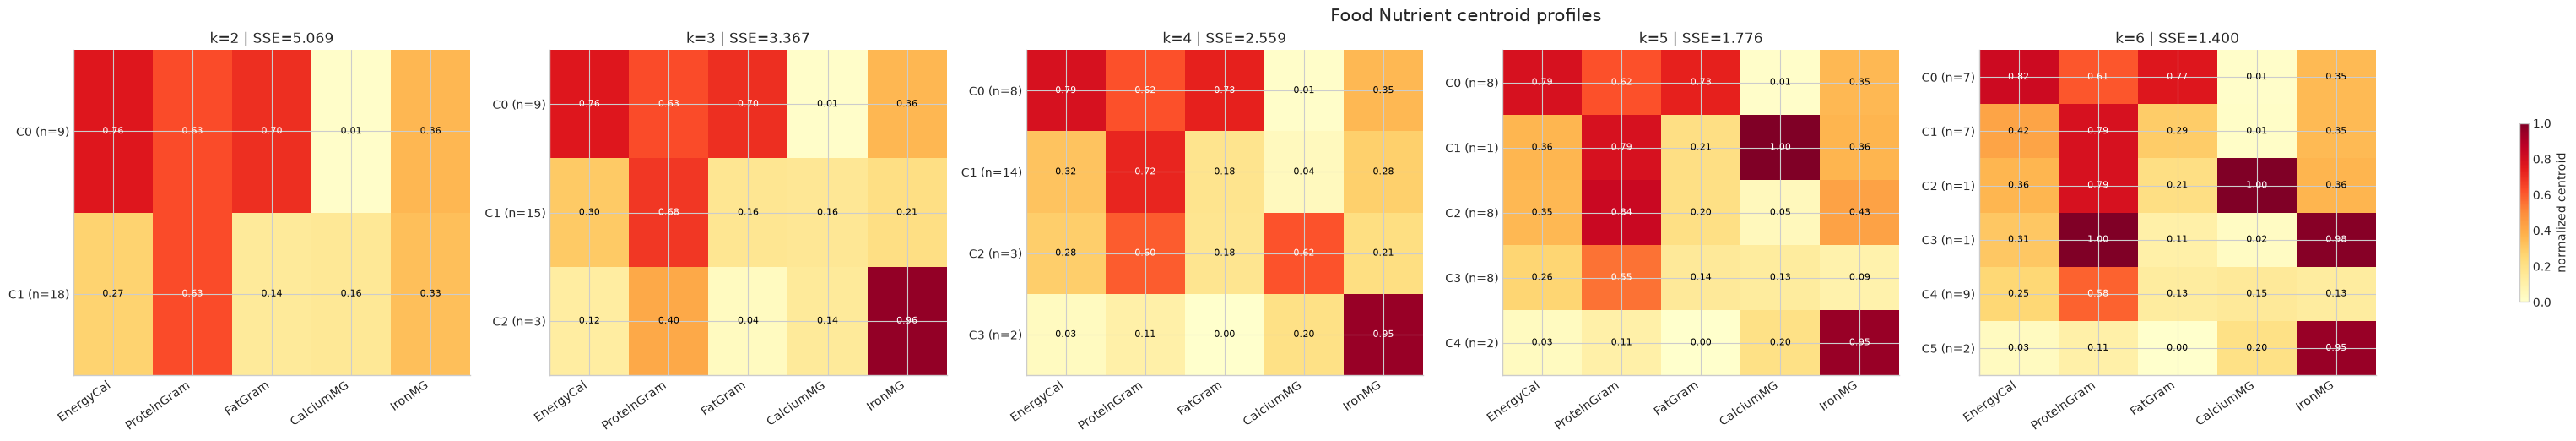

In [59]:
fig, axes = plt.subplots(1, 5, figsize=(44, 5))
for ax, k in zip(axes.flat, range(2, 7)):
    _, _, centers, _, _, sizes = food_results[k]
    image = ax.imshow(centers, cmap="YlOrRd", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(food_features)), food_features, rotation=35, ha="right")
    ax.set_yticks(range(k), [f"C{i} (n={sizes.iloc[i]})" for i in range(k)])
    ax.set_title(f"k={k} | SSE={food_results[k][0].inertia_:.3f}")
    for i in range(k):
        for j in range(len(food_features)):
            value = centers.iloc[i, j]
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="white" if value > .55 else "black", fontsize=8)
fig.colorbar(image, ax=axes.ravel().tolist(), shrink=.55, label="normalized centroid")
fig.suptitle("Food Nutrient centroid profiles", fontsize=15)
plt.show()


## Food cluster centers


In [60]:
#| echo: false

model, labels, centers, centers_original, stds, sizes = food_results[2]
print(f"SSE = {model.inertia_:.3f}")
table = centers_original.round(1).copy()
table.insert(0, "size", sizes)
table


SSE = 5.069


,size,EnergyCal,ProteinGram,FatGram,CalciumMG,IronMG
C0,9,331.1,19.0,27.6,8.8,2.5
C1,18,145.6,19.0,6.4,61.6,2.3


In [61]:
#| echo: false

model, labels, centers, centers_original, stds, sizes = food_results[3]
print(f"SSE = {model.inertia_:.3f}")
table = centers_original.round(1).copy()
table.insert(0, "size", sizes)
table


SSE = 3.367


,size,EnergyCal,ProteinGram,FatGram,CalciumMG,IronMG
C0,9,331.1,19.0,27.6,8.8,2.5
C1,15,156.3,19.9,7.3,62.5,1.7
C2,3,91.7,14.7,2.3,56.7,5.8


In [62]:
#| echo: false

model, labels, centers, centers_original, stds, sizes = food_results[4]
print(f"SSE = {model.inertia_:.3f}")
table = centers_original.round(1).copy()
table.insert(0, "size", sizes)
table


SSE = 2.559


,size,EnergyCal,ProteinGram,FatGram,CalciumMG,IronMG
C0,8,341.9,18.7,28.9,8.7,2.4
C1,14,163.9,20.7,7.7,19.9,2.0
C2,3,151.7,18.3,7.7,227.7,1.7
C3,2,57.5,9.0,1.0,78.0,5.7


## Food cluster centers


In [63]:
#| echo: false

model, labels, centers, centers_original, stds, sizes = food_results[5]
print(f"SSE = {model.inertia_:.3f}")
table = centers_original.round(1).copy()
table.insert(0, "size", sizes)
table


SSE = 1.776


,size,EnergyCal,ProteinGram,FatGram,CalciumMG,IronMG
C0,8,341.9,18.7,28.9,8.7,2.4
C1,1,180.0,22.0,9.0,367.0,2.5
C2,8,178.1,22.9,8.8,21.6,2.8
C3,8,143.1,17.5,6.5,52.6,1.0
C4,2,57.5,9.0,1.0,78.0,5.7


In [64]:
#| echo: false

model, labels, centers, centers_original, stds, sizes = food_results[6]
print(f"SSE = {model.inertia_:.3f}")
table = centers_original.round(1).copy()
table.insert(0, "size", sizes)
table


SSE = 1.400


,size,EnergyCal,ProteinGram,FatGram,CalciumMG,IronMG
C0,7,352.9,18.6,30.1,8.7,2.4
C1,7,202.9,22.0,12.0,10.0,2.4
C2,1,180.0,22.0,9.0,367.0,2.5
C3,1,160.0,26.0,5.0,14.0,5.9
C4,9,139.4,18.1,5.9,57.7,1.2
C5,2,57.5,9.0,1.0,78.0,5.7


## Food Nutrient interpretation

<details>
<summary>Answer</summary>

Across increasing $k$, the stable, interpretable profiles are:

- high-energy, high-fat foods;
- high-protein foods with lower fat and energy;
- light but calcium-rich foods;
- a singleton extreme-calcium food when the partition isolates one observation;
- foods with middle-range energy, protein, and fat;
- a light/low-fat but protein-, calcium-, or iron-rich group at the finer partition.

</br>

Iron is often weakly characterized because most values are similar and a few high-iron foods dominate its range.

- Small clusters should be treated cautiously: lower SSE alone does not guarantee a useful segmentation.
</details>


## Verify against the classified file

`FoodNutrientsClassified.arff` contains descriptive fields (`SuperType`, preparation, `Type`, and `Name`) followed by the same numeric nutrients. They are used only to interpret the already fitted $k=6$ clusters.


In [75]:
food_classified = load_arff_frame("FoodNutrientsClassified.arff")
food_classified.head(10)

,SuperType,Preparated,Type,Name,EnergyCal,ProteinGram,FatGram,CalciumMG,IronMG
0,MEAT,COOKED,BEEF,BEEF_BRAISED,340.0,20.0,28.0,9.0,2.6
1,MEAT,COOKED,BEEF,HAMBURGER,245.0,21.0,17.0,9.0,2.7
2,MEAT,COOKED,BEEF,BEEF_ROAST,420.0,15.0,39.0,7.0,2.0
3,MEAT,COOKED,BEEF,BEEF_STEAK,375.0,19.0,32.0,9.0,2.6
4,MEAT,CANNED,BEEF,BEEF_CANNED,180.0,22.0,10.0,17.0,3.7
5,MEAT,BROILED,CHICKEN,CHICKEN_BROILED,115.0,20.0,3.0,8.0,1.4
6,MEAT,CANNED,CHICKEN,CHICKEN_CANNED,170.0,25.0,7.0,12.0,1.5
7,MEAT,BROILED,BEEF,BEEF_HEART,160.0,26.0,5.0,14.0,5.9
8,MEAT,COOKED,LAMB,LAMB_LEG_ROAST,265.0,20.0,20.0,9.0,2.6
9,MEAT,COOKED,LAMB,LAMB_SHOULDER_ROAST,300.0,18.0,25.0,9.0,2.3


## Food clusters by super type


In [76]:
labels6 = food_results[6][1]
food_labeled = food_classified[["Name", "SuperType", "Type"]].copy()
food_labeled.insert(0, "cluster", [f"C{i}" for i in labels6])
food_labeled.head(10)

,cluster,Name,SuperType,Type
0,C0,BEEF_BRAISED,MEAT,BEEF
1,C1,HAMBURGER,MEAT,BEEF
2,C0,BEEF_ROAST,MEAT,BEEF
3,C0,BEEF_STEAK,MEAT,BEEF
4,C1,BEEF_CANNED,MEAT,BEEF
5,C4,CHICKEN_BROILED,MEAT,CHICKEN
6,C1,CHICKEN_CANNED,MEAT,CHICKEN
7,C3,BEEF_HEART,MEAT,BEEF
8,C1,LAMB_LEG_ROAST,MEAT,LAMB
9,C0,LAMB_SHOULDER_ROAST,MEAT,LAMB


In [67]:
pd.crosstab(food_labeled["cluster"], food_labeled["SuperType"], margins=True)


SuperType,FISH,MEAT,All
cluster,,,
C0,0,7,7
C1,1,6,7
C2,1,0,1
C3,0,1,1
C4,8,1,9
C5,2,0,2
All,12,15,27


## Food clusters by type


In [68]:
pd.crosstab(food_labeled["cluster"], food_labeled["Type"], margins=True)


Type,BEEF,CHICKEN,CLAMS,FISH,LAMB,PORK,SHELLFISH,All
cluster,,,,,,,,
C0,3,0,0,0,1,3,0,7
C1,4,1,0,1,1,0,0,7
C2,0,0,0,1,0,0,0,1
C3,1,0,0,0,0,0,0,1
C4,0,1,0,6,0,0,2,9
C5,0,0,2,0,0,0,0,2
All,8,2,2,8,2,3,2,27


## Food cluster members


In [69]:
for cluster, group in food_labeled.groupby("cluster", sort=True):
    print(f"{cluster}: " + ", ".join(group["Name"]))


C0: BEEF_BRAISED, BEEF_ROAST, BEEF_STEAK, LAMB_SHOULDER_ROAST, SMOKED_HAM, PORK_ROAST, PORK_SIMMERED
C1: HAMBURGER, BEEF_CANNED, CHICKEN_CANNED, LAMB_LEG_ROAST, BEEF_TONGUE, VEAL_CUTLET, TUNA_CANNED
C2: SARDINES_CANNED
C3: BEEF_HEART
C4: CHICKEN_BROILED, BLUEFISH_BAKED, CRABMEAT_CANNED, HADDOCK_FRIED, MACKEREL_BROILED, MACKEREL_CANNED, PERCH_FRIED, SALMON_CANNED, SHRIMP_CANNED
C5: CLAMS_RAW, CLAMS_CANNED


# Coordinates dataset: K-means

## The Coordinates dataset: K-means

Coordinates contains 480 two-dimensional points.

- We first repeat the $k=2\ldots6$ experiment and inspect how SSE changes.
- Because scikit-learn reports the **sum** of squared distances while the Weka slide values depend on its own normalization and reporting convention, absolute SSE values need not match; the trend and geometry are the comparison that matter.


In [70]:
coordinates = load_arff_frame("Coordinates.arff")
coordinate_features = ["X", "Y"]
coordinate_scaler = MinMaxScaler()
X_coordinates = coordinate_scaler.fit_transform(coordinates[coordinate_features])

coordinate_models = {}
for k in range(2, 7):
    model = KMeans(n_clusters=k, n_init=20, random_state=10)
    labels = model.fit_predict(X_coordinates)
    coordinate_models[k] = (model, labels)

coordinate_sse = pd.DataFrame({
    "k": range(2, 7),
    "SSE": [coordinate_models[k][0].inertia_ for k in range(2, 7)],
})
coordinate_sse["SSE reduction"] = coordinate_sse["SSE"].shift(1) - coordinate_sse["SSE"]
coordinate_sse.round(3)


,k,SSE,SSE reduction
0,2,29.177,NaN
1,3,18.709,10.468
2,4,12.060,6.649
3,5,9.539,2.520
4,6,7.738,1.802


# K-means

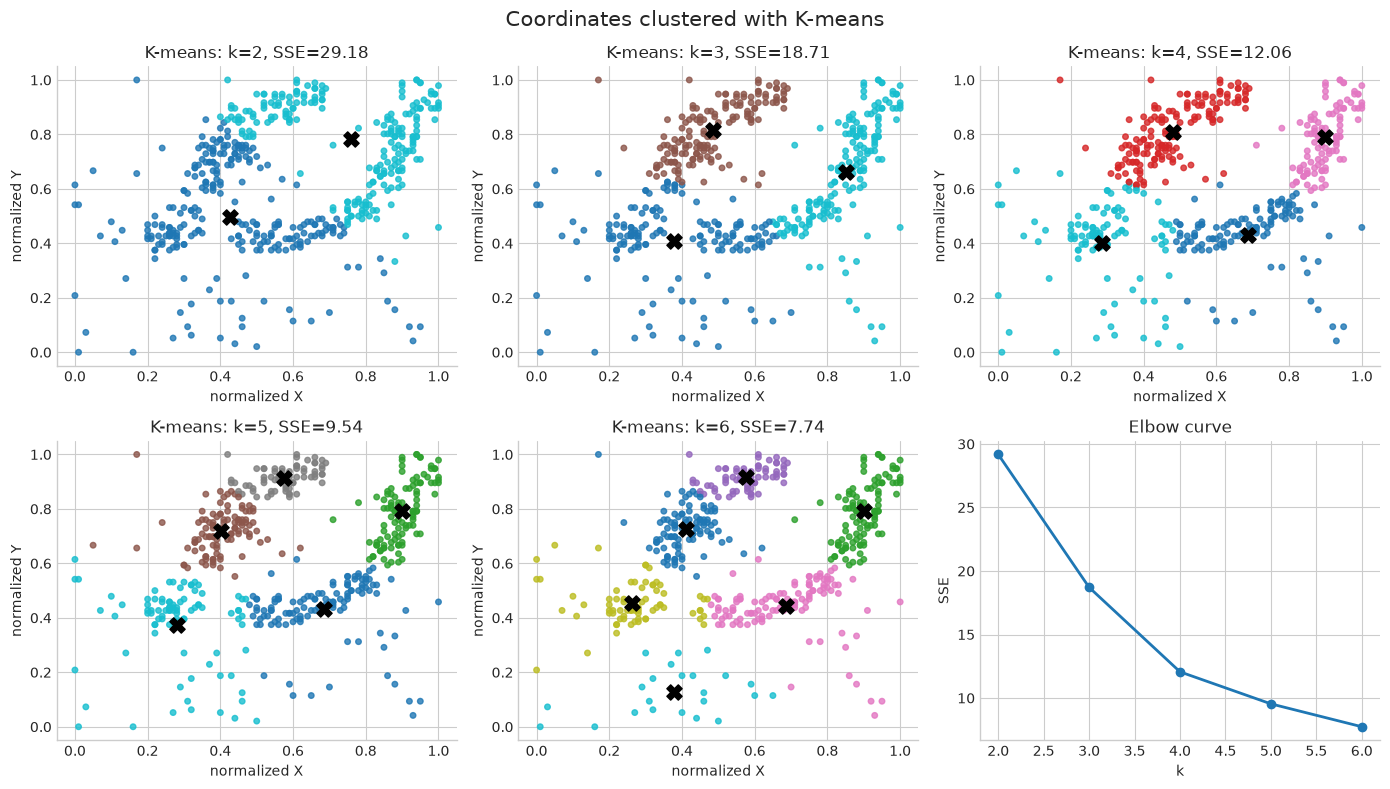

In [71]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, k in zip(axes.flat, range(2, 7)):
    model, labels = coordinate_models[k]
    ax.scatter(X_coordinates[:, 0], X_coordinates[:, 1], c=labels, cmap="tab10", s=16, alpha=.8)
    ax.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1], c="black", marker="X", s=120)
    ax.set(title=f"K-means: k={k}, SSE={model.inertia_:.2f}", xlabel="normalized X", ylabel="normalized Y")
axes.flat[-1].plot(coordinate_sse["k"], coordinate_sse["SSE"], marker="o", linewidth=2)
axes.flat[-1].set(title="Elbow curve", xlabel="k", ylabel="SSE")
fig.suptitle("Coordinates clustered with K-means", fontsize=15)
plt.tight_layout()
plt.show()


## K-means conclusion

SSE necessarily decreases as $k$ grows, with diminishing improvements around the handout's suggested $k\approx5$.

- But the plots expose the more important limitation: K-means divides elongated natural groups into compact Voronoi regions.
- Adding centroids reduces SSE by slicing the shapes rather than discovering their full extent.
- **A density-based method is preferable**.


## The Coordinates dataset: DBSCAN

DBSCAN replaces a chosen number of clusters with two density parameters:

- `eps`: neighborhood radius;
- `min_samples`: minimum number of points (including the point itself) needed to define a core point.



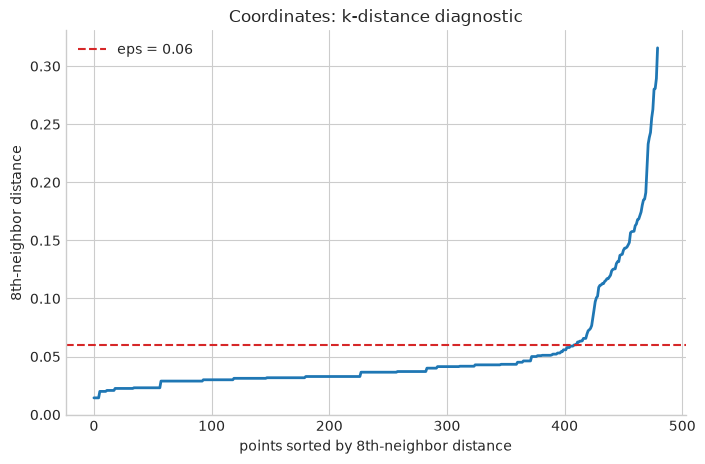

In [72]:
# A k-distance plot helps identify a bend for min_samples=8.
neighbors = NearestNeighbors(n_neighbors=8).fit(X_coordinates)
distances, _ = neighbors.kneighbors(X_coordinates)
k_distances = np.sort(distances[:, -1])

plt.plot(k_distances, linewidth=2)
plt.axhline(.06, color="tab:red", linestyle="--", label="eps = 0.06")
plt.xlabel("points sorted by 8th-neighbor distance")
plt.ylabel("8th-neighbor distance")
plt.title("Coordinates: k-distance diagnostic")
plt.legend()
plt.show()


# DBSCAN


The handout explores `(eps, minPts)` values `(0.10,4)`, `(0.10,8)`, `(0.05,4)`, `(0.06,3)`, and `(0.06,8)` on normalized coordinates.

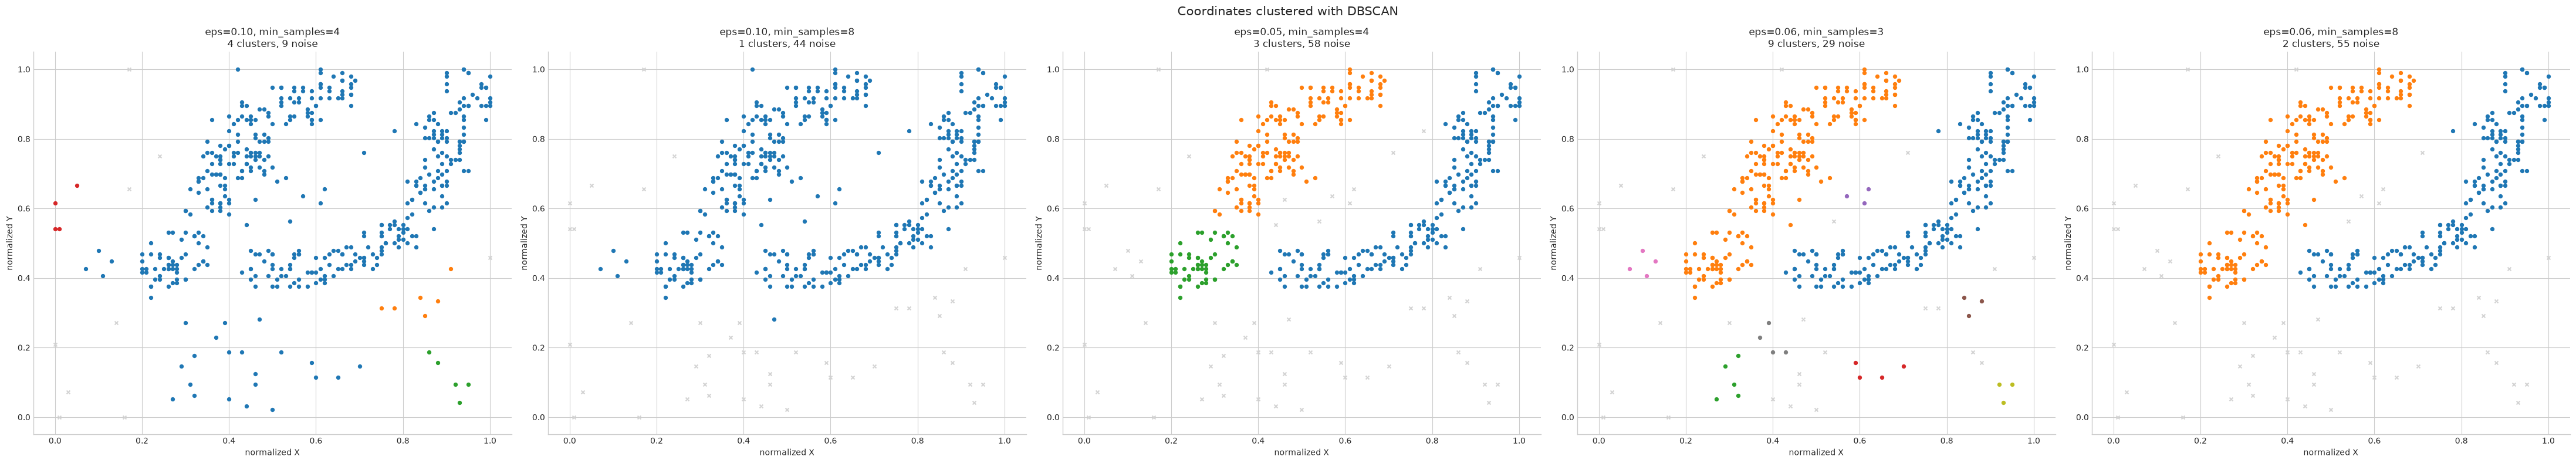

In [73]:
#| echo: false

dbscan_settings = [(.10, 4), (.10, 8), (.05, 4), (.06, 3), (.06, 8)]
dbscan_results = {}

fig, axes = plt.subplots(1, 5, figsize=(44, 8))
for ax, (eps, min_samples) in zip(axes.flat, dbscan_settings):
    model = DBSCAN(eps=eps, min_samples=min_samples)
    labels = model.fit_predict(X_coordinates)
    dbscan_results[(eps, min_samples)] = labels

    unique = sorted(set(labels))
    for label in unique:
        mask = labels == label
        if label == -1:
            ax.scatter(X_coordinates[mask, 0], X_coordinates[mask, 1], c="lightgray", s=18, marker="x", label="noise")
        else:
            ax.scatter(X_coordinates[mask, 0], X_coordinates[mask, 1], s=18, label=f"C{label}")

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)
    ax.set(
        title=f"eps={eps:.2f}, min_samples={min_samples}\n{n_clusters} clusters, {n_noise} noise",
        xlabel="normalized X", ylabel="normalized Y",
    )

fig.suptitle("Coordinates clustered with DBSCAN", fontsize=15)
plt.tight_layout()
plt.show()


In [74]:
#| echo: false

dbscan_summary = []
for (eps, min_samples), labels in dbscan_results.items():
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int(np.sum(labels == -1))
    clustered = labels != -1
    silhouette = (
        silhouette_score(X_coordinates[clustered], labels[clustered])
        if n_clusters >= 2 and clustered.sum() > n_clusters else np.nan
    )
    dbscan_summary.append({
        "eps": eps, "min_samples": min_samples,
        "clusters": n_clusters, "noise points": n_noise,
        "noise %": n_noise / len(labels), "silhouette (non-noise)": silhouette,
    })

dbscan_summary = pd.DataFrame(dbscan_summary)
dbscan_summary["eps"] = dbscan_summary["eps"].map(lambda value: f"{value:.2f}")
dbscan_summary["noise %"] = dbscan_summary["noise %"].map(lambda value: f"{value:.1%}")
dbscan_summary["silhouette (non-noise)"] = dbscan_summary["silhouette (non-noise)"].map(
    lambda value: "n/a" if pd.isna(value) else f"{value:.3f}"
)
dbscan_summary


,eps,min_samples,clusters,noise points,noise %,silhouette (non-noise)
0,0.10,4,4,9,1.9%,0.012
1,0.10,8,1,44,9.2%,n/a
2,0.05,4,3,58,12.1%,0.396
3,0.06,3,9,29,6.0%,-0.033
4,0.06,8,2,55,11.5%,0.395


## DBSCAN interpretation

<details>
<summary>Answer</summary>

The plots reproduce the handout's parameter reasoning:

- `eps=0.10, min_samples=4`: neighborhoods connect too easily, so distinct dense areas merge;
- `eps=0.10, min_samples=8`: the stronger density requirement helps with noise but the radius can still bridge natural groups;
- `eps=0.05, min_samples=4`: the small radius and low threshold can fragment dense shapes;
- `eps=0.06, min_samples=3`: the density threshold is too permissive to reject noise reliably;
- **`eps=0.06, min_samples=8`**: best balance among the tested settings, recovering elongated clusters while rejecting sparse points.

Unlike K-means, DBSCAN can trace non-spherical shapes and mark observations as noise (`label == -1`). Its parameters are scale-dependent, which is why the same normalization used by the handout is essential.
</details>


## Takeaways

1. Normalize before Euclidean-distance clustering when attributes have different ranges.
2. Read K-means beyond a single score: inspect centroids, dispersion, sizes, stability, and geometry.
3. Known labels may evaluate a clustering, but they must not enter the clustering features.
4. SSE always falls with larger $k$; look for diminishing returns and whether clusters remain meaningful.
5. K-means favors compact center-based clusters. DBSCAN is better suited to elongated shapes and explicit noise.
6. Cluster IDs are arbitrary. Interpret a cluster through its profile and members, not its number.


## Kaggle assignment: customer segmentation

Use the public Kaggle dataset [Customer Personality Analysis](https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis) to build and interpret customer segments.

Your task:

1. Load the dataset and define a clear segmentation goal, such as identifying customer groups for marketing actions.
2. Clean the data, handle missing values, engineer useful features such as age, total spending, family size, or campaign acceptance, and scale numeric variables before distance-based clustering.
3. Compare at least two clustering approaches, for example K-means and hierarchical clustering or DBSCAN. For K-means, justify the selected number of clusters using elbow and silhouette evidence.
4. Profile each cluster with tables and plots, then assign a short business label to every cluster.
5. Explain one limitation of the analysis, including whether any variables could introduce bias or make the clusters hard to act on.
